In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
from PF2nlfff.packages import *
from PF2nlfff.model_3D import *
from PF2nlfff.tools import *
from PF2nlfff.nlfff_module import *

In [3]:
PF_data = np.load('../TD_model/GUO_data/potential_field/PF_td_N3_0.06.npy').astype(np.float32)
nlfff_data = np.load('../TD_model/GUO_data/td_N3_0.06.npy').astype(np.float32)
nlfff_data = adc_shape(nlfff_data, is_print_info=False)
PF_data = adc_shape(PF_data, is_print_info=False)
n3 = np.min([nlfff_data.shape[3],PF_data.shape[3]])
nlfff_data = nlfff_data[:,:,:,:n3]
PF_data = PF_data[:,:,:,:n3]

In [4]:
gan_model = torch.load('GAN_model/best_model.pkl')
import copy
netG = copy.deepcopy(gan_model.netG)
model = PICNN(PF_data, net=netG, device=torch.device('cuda:1'))

PF_tensor = torch.from_numpy(PF_data).unsqueeze(0).cuda()
model.net.eval()
with torch.no_grad():
    gen_data = gan_model.netG(PF_tensor)[0].detach().cpu().numpy()
TD_data = nlfff_data

In [ ]:
model.L_ff  = 1.e2
model.L_div = 1.e2
model.L_bc  = 5.e8
model.L_Sj  = 1.e1
model.L_fi  = 1.e3
model.L_lf  = 1.e4
model.print_epoch=100
model.save_epoch=10000
model._use_mf = True
LR = 1.e-3
# LR = 'continue'
step_size = 80
gamma=0.995
model.train(50001, lr=LR, Delta=step_size, gamma=gamma, save_best=False, save_first=False,
            save_models_dir='./trainer/TD_model_v1', save_model_name='retrained_TD'
           )

/home/aiia/newDisk/gychen/PF2nlfff_beta_v2/codes/PF2nlfff/mf_module.py:275: UserWarning: Using torch.cross without specifying the dim arg is deprecated.
Please either pass the dim explicitly or simply use torch.linalg.cross.
The default value of dim will change to agree with that of linalg.cross in a future release. (Triggered internally at /opt/conda/conda-bld/pytorch_1712608935911/work/aten/src/ATen/native/Cross.cpp:62.)
  axb = torch.cross(a, b).reshape(size).permute(3,0,1,2)


Iter 00000, Loss: 1.113e+10, Loss_div: 5.075e+08,Loss_ff: 1.684e+09, Loss_bc: 8.698e+09, Loss_lf: 2.445e+08, wall_time: 1.014e+00 sec, lr: 1.000e-03
Iter 00100, Loss: 4.720e+06, Loss_div: 7.229e+05,Loss_ff: 1.414e+06, Loss_bc: 2.584e+06, Loss_lf: 1.836e+02, wall_time: 9.714e+01 sec, lr: 9.752e-04
Iter 00200, Loss: 1.769e+06, Loss_div: 2.966e+05,Loss_ff: 5.508e+05, Loss_bc: 9.218e+05, Loss_lf: 3.279e+01, wall_time: 1.936e+02 sec, lr: 9.511e-04
Iter 00300, Loss: 1.064e+06, Loss_div: 1.900e+05,Loss_ff: 3.228e+05, Loss_bc: 5.510e+05, Loss_lf: 1.554e+01, wall_time: 2.902e+02 sec, lr: 9.276e-04
Iter 00400, Loss: 1.230e+06, Loss_div: 1.390e+05,Loss_ff: 2.283e+05, Loss_bc: 8.622e+05, Loss_lf: 9.993e+00, wall_time: 3.867e+02 sec, lr: 9.046e-04
Iter 00500, Loss: 6.019e+05, Loss_div: 9.947e+04,Loss_ff: 1.813e+05, Loss_bc: 3.211e+05, Loss_lf: 6.637e+00, wall_time: 4.834e+02 sec, lr: 8.822e-04
Iter 00600, Loss: 5.621e+05, Loss_div: 7.739e+04,Loss_ff: 1.524e+05, Loss_bc: 3.322e+05, Loss_lf: 6.835e+0

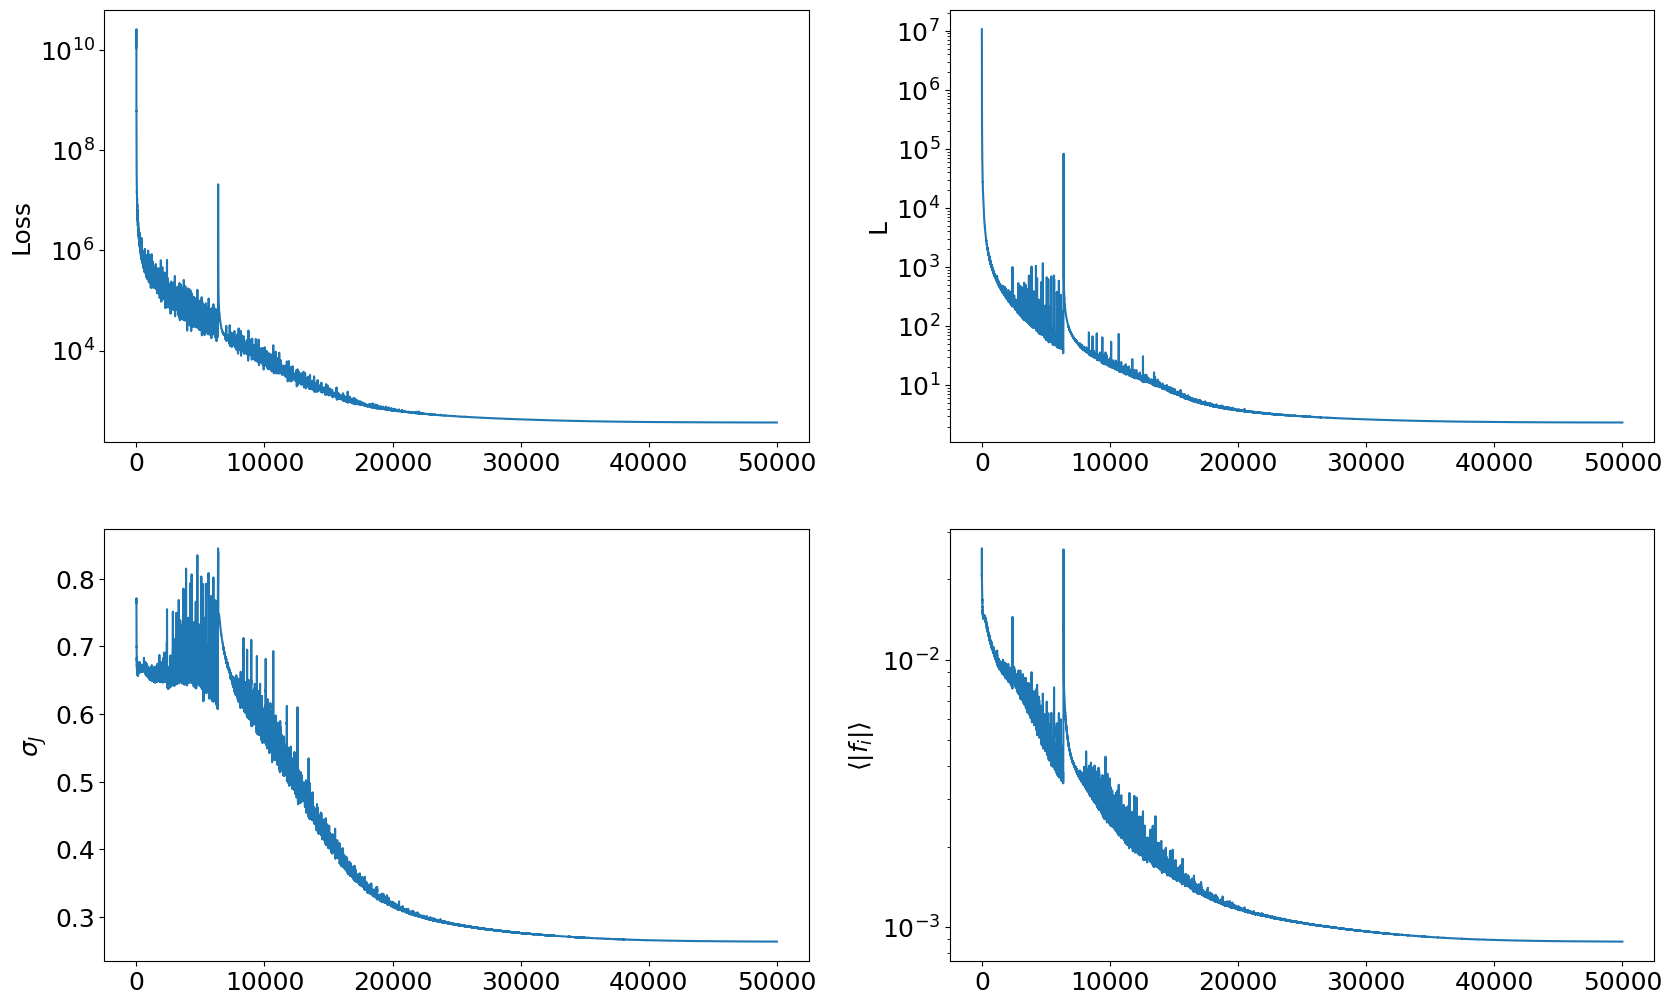

In [11]:
plt.rcParams['font.size'] = 18
plt.figure(figsize=(20,6.18*2))
plt.subplot(221)
plt.plot(model.loss_list)
plt.yscale('log')
plt.ylabel('Loss')

plt.subplot(222)
plt.plot(model.L_list)
plt.yscale('log')
plt.ylabel('L')

plt.subplot(223)
plt.plot(model.sJ_list)
plt.ylabel('$\sigma_J$')

plt.subplot(224)
plt.plot(model.fi_list)
plt.yscale('log')
plt.ylabel(r'$\left<\|f_i\|\right>$')

plt.show()